# Graph Transformer — Fixed Architecture, Batch of Feature Configurations (HI-Small)

- **Question:** what do engineered edge features add when the GNN architecture is held *exactly* fixed?
- **Knobs per config:** `mp` = edge features in message passing (`none` / `base` / `full`), `readout` = edge features at the classifier (`base` / `full` / `gfp`). Direction and temporal sampling are fixed per batch.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`. This notebook only sets `OPERATOR`, the config batch and paths.
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must be **133,121** in every run.

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 165.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 227.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 169.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 74.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 102.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 149.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 185 (delta 72), reused 144 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (185/185), 5.74 MiB | 16.33 MiB/s, done.
Resolving deltas: 100% (72/72), done.
cac41f9 (HEAD -> main, origin/main, origin/HEAD) Add Graph Transformer operator (TransformerConv, 4 heads x 32, edge_dim, PyG defaults) to gnn_core.py; TRANSFORMER_fixed_architecture.ipynb with the seven configs; docs: Transformer invariant_params 133,121, totals 168,577-197,121; EXPERIMENTS TR-4/TR-5 order fixed; CLAUDE.md cell 9 exception for PNA


## 1. Configuration

- The only cell that differs between operator notebooks (`GIN_` / `PNA_` / `GAT_` / `TRANSFORMER_`).
- `CONFIGS`: one dict per run of this batch; run numbers refer to `EXPERIMENTS.md`.
- `OUT_ROOT` mirrors `Outputs/TRANSFORMER/` in the repo; the zip in section 6 is what gets committed (minus `best.pt`).

In [3]:
OPERATOR = 'transformer'

# knob configs of this batch — one dict per run
CONFIGS = [
    dict(mp='none', readout='base'),   # TR-1 — topology alone, the reference point
    dict(mp='base', readout='base'),   # TR-2 — edge features inside message passing
    dict(mp='none', readout='full'),   # TR-3 — GFP only at the decision layer
    dict(mp='full', readout='full'),   # TR-4 — GFP everywhere
    dict(mp='base', readout='full'),   # TR-5 — GFP at the decision layer only
    dict(mp='base', readout='gfp'),    # TR-6 — are raw features redundant once message passing has used them?
    dict(mp='none', readout='gfp'),    # TR-7 — GFP alone vs baseline alone (compare with TR-1)
]
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
OUT_ROOT    = '/kaggle/working/Outputs/TRANSFORMER'      # mirrors Outputs/TRANSFORMER/ in the repo

import gnn_core as core
os.makedirs(OUT_ROOT, exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 61, full = all 81.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR)

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`.
- `TransformerConv`, 4 heads × 32 concatenated = 128: attention with edge features over the sampled neighbourhood (local, not full-graph); `mp ≠ none` adds only the edge projection `lin_edge(edge_dim)`.
- Between configs only `lin_edge` and the readout's first `Linear` change width; `invariant_params` counts the rest and must be 133,121.

In [5]:
cfg = CONFIGS[0]
model = core.build_model(OPERATOR, node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional')
print(model)
print(f'params {core.count_params(model):,} | invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=6, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): TransformerConv(128, 32, heads=4)
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=276, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
params 168,577 | invariant_params 133,121   (config {'mp': 'none', 'readout': 'base'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== transformer_mp-none_readout-base_dir-in ===
MP edge features: 0 | readout edge features: 20
total params: 168,577 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0170 / 0.0227 | F1 0.2976 / 0.4268 @ 0.274 | PR-AUC 0.2989 / 0.3462 | 65s | RAM 6.6GB   (train / val)
best validation F1 0.4276 at epoch 18 (threshold 0.265)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.2999  0.4267  0.3699
precision          0.2606  0.5372  0.3890
recall             0.3531  0.3540  0.3526
pr_auc             0.2993  0.3466  0.3372
roc_auc            0.9766  0.9743  0.9754
precision_at_5pct  0.0124  0.0177  0.0188
recall_at_5pct     0.8219  0.8327  0.8346
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-none_readout-base_dir-in/predictions.csv


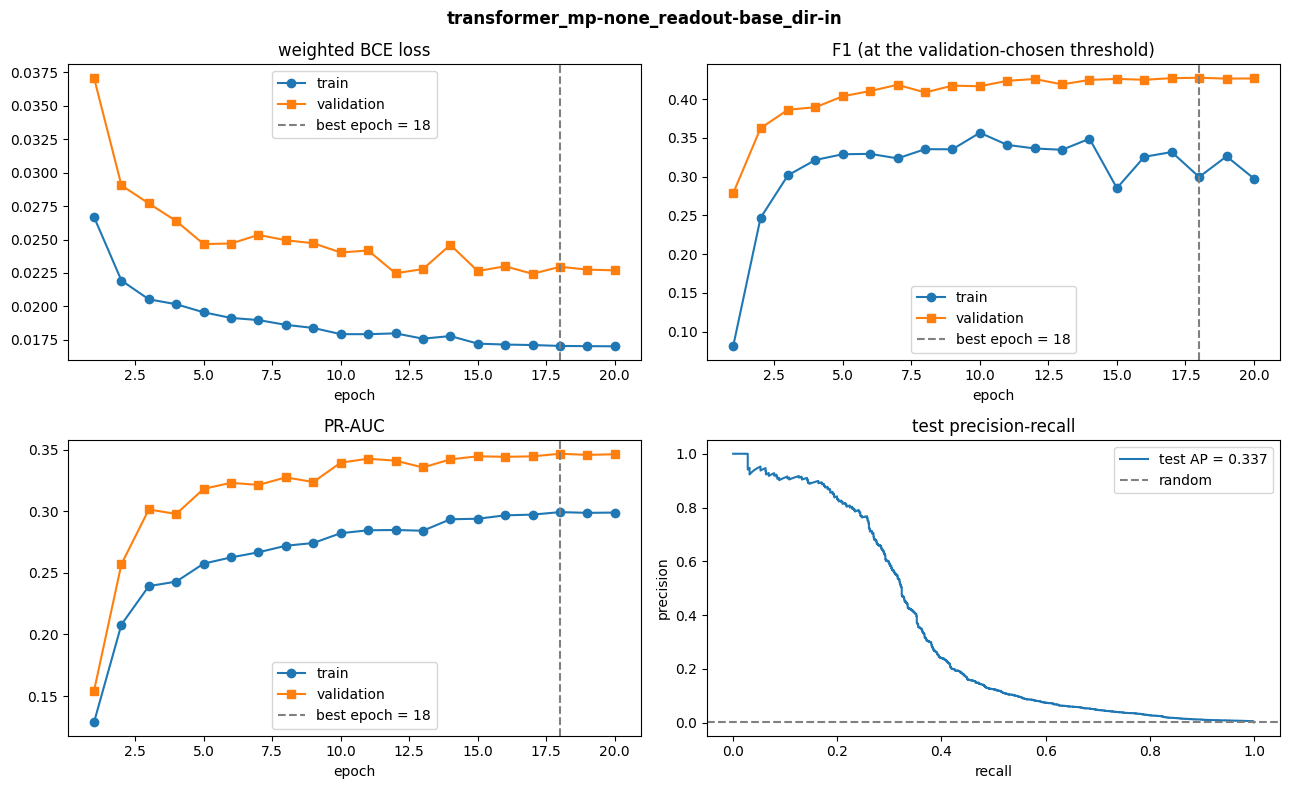

=== transformer_mp-base_readout-base_dir-in ===
MP edge features: 20 | readout edge features: 20
total params: 173,697 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0111 / 0.0164 | F1 0.5740 / 0.6227 @ 0.554 | PR-AUC 0.5504 / 0.5619 | 87s | RAM 7.7GB   (train / val)
best validation F1 0.6243 at epoch 18 (threshold 0.578)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5738  0.6243  0.5856
precision          0.7306  0.8578  0.8021
recall             0.4724  0.4908  0.4611
pr_auc             0.5490  0.5633  0.5490
roc_auc            0.9897  0.9835  0.9837
precision_at_5pct  0.0137  0.0185  0.0197
recall_at_5pct     0.9094  0.8660  0.8731
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-base_readout-base_dir-in/predictions.csv


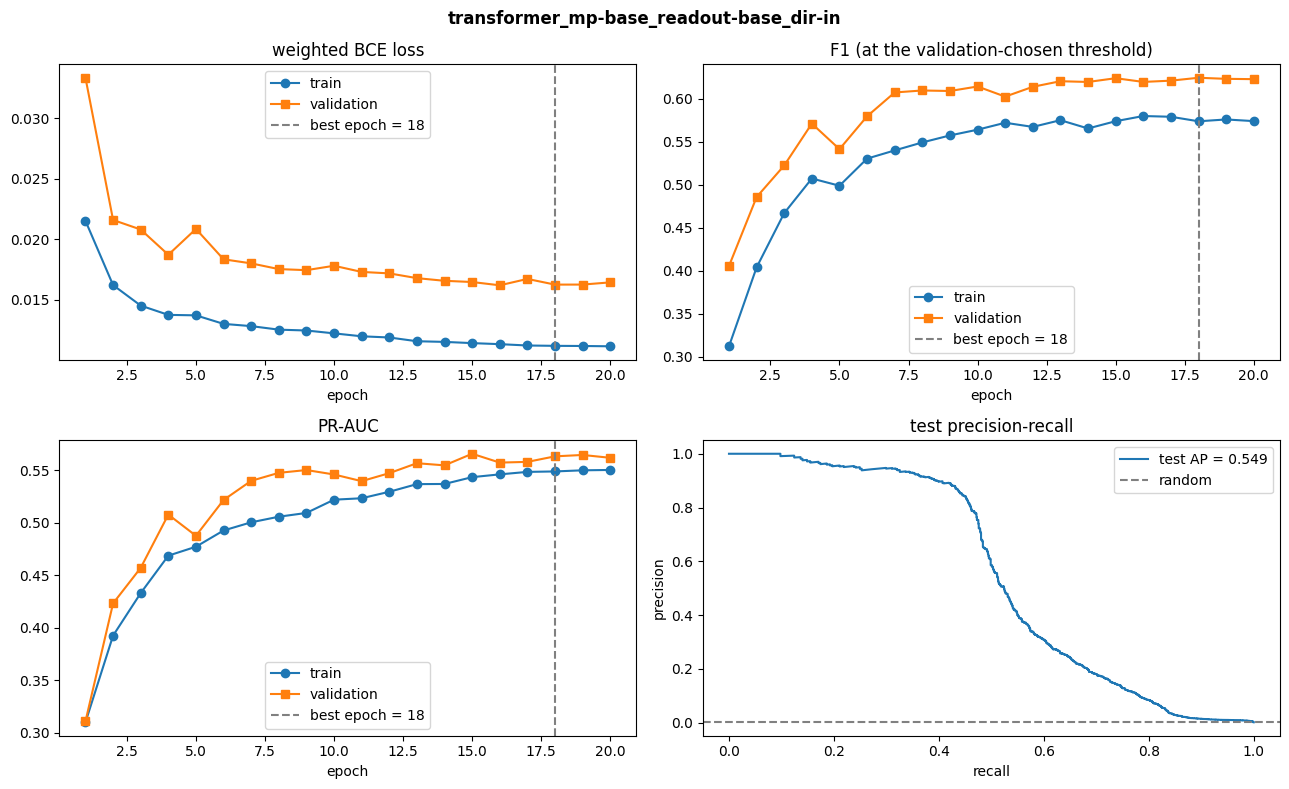

=== transformer_mp-none_readout-full_dir-in ===
MP edge features: 0 | readout edge features: 81
total params: 176,385 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0149 / 0.0196 | F1 0.4372 / 0.5112 @ 0.454 | PR-AUC 0.3798 / 0.4412 | 65s | RAM 7.9GB   (train / val)   * new best -> best.pt
best validation F1 0.5112 at epoch 20 (threshold 0.454)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4372  0.5112  0.4482
precision          0.5169  0.6496  0.5345
recall             0.3788  0.4214  0.3858
pr_auc             0.3798  0.4412  0.4109
roc_auc            0.9833  0.9795  0.9794
precision_at_5pct  0.0132  0.0181  0.0193
recall_at_5pct     0.8746  0.8494  0.8556
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-none_readout-full_dir-in/predictions.csv


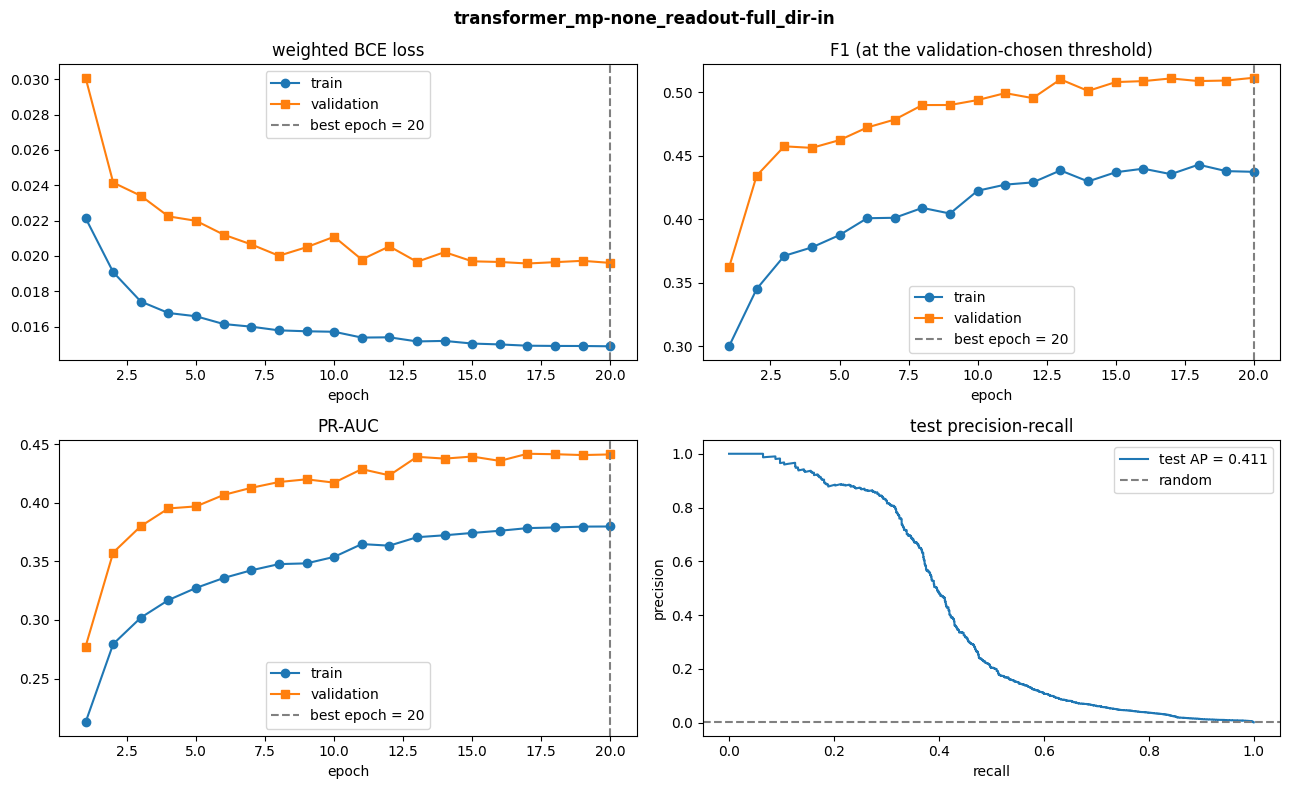

=== transformer_mp-full_readout-full_dir-in ===
MP edge features: 81 | readout edge features: 81
total params: 197,121 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0095 / 0.0175 | F1 0.6034 / 0.6402 @ 0.667 | PR-AUC 0.6017 / 0.5862 | 147s | RAM 11.6GB   (train / val)
best validation F1 0.6440 at epoch 15 (threshold 0.698)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5970  0.6440  0.6022
precision          0.8137  0.8786  0.7878
recall             0.4715  0.5083  0.4873
pr_auc             0.5869  0.5878  0.5744
roc_auc            0.9932  0.9810  0.9830
precision_at_5pct  0.0144  0.0182  0.0198
recall_at_5pct     0.9547  0.8540  0.8810
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-full_readout-full_dir-in/predictions.csv


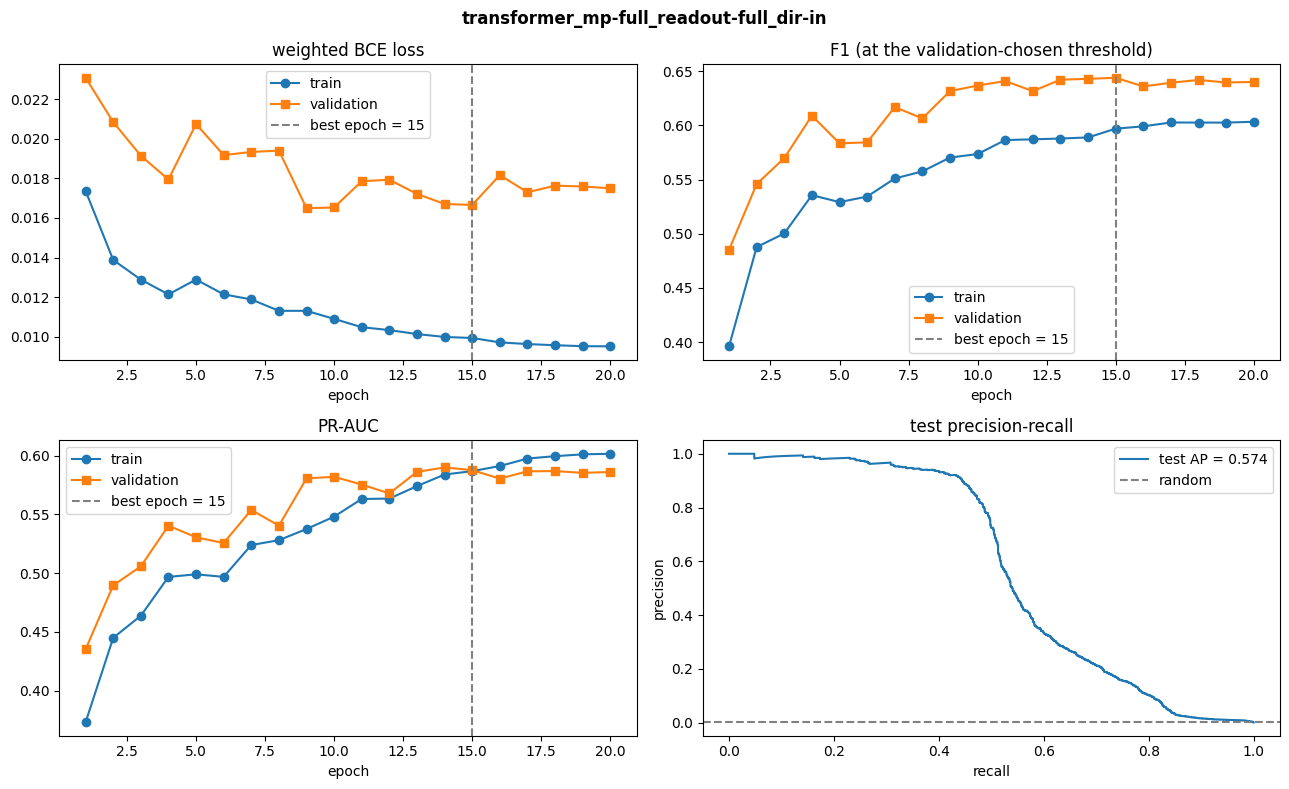

=== transformer_mp-base_readout-full_dir-in ===
MP edge features: 20 | readout edge features: 81
total params: 181,505 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0110 / 0.0164 | F1 0.5738 / 0.6220 @ 0.629 | PR-AUC 0.5461 / 0.5695 | 88s | RAM 8.9GB   (train / val)
best validation F1 0.6287 at epoch 14 (threshold 0.681)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5689  0.6287  0.5975
precision          0.8131  0.8929  0.8315
recall             0.4375  0.4852  0.4663
pr_auc             0.5382  0.5771  0.5532
roc_auc            0.9900  0.9838  0.9831
precision_at_5pct  0.0139  0.0185  0.0196
recall_at_5pct     0.9229  0.8669  0.8714
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-base_readout-full_dir-in/predictions.csv


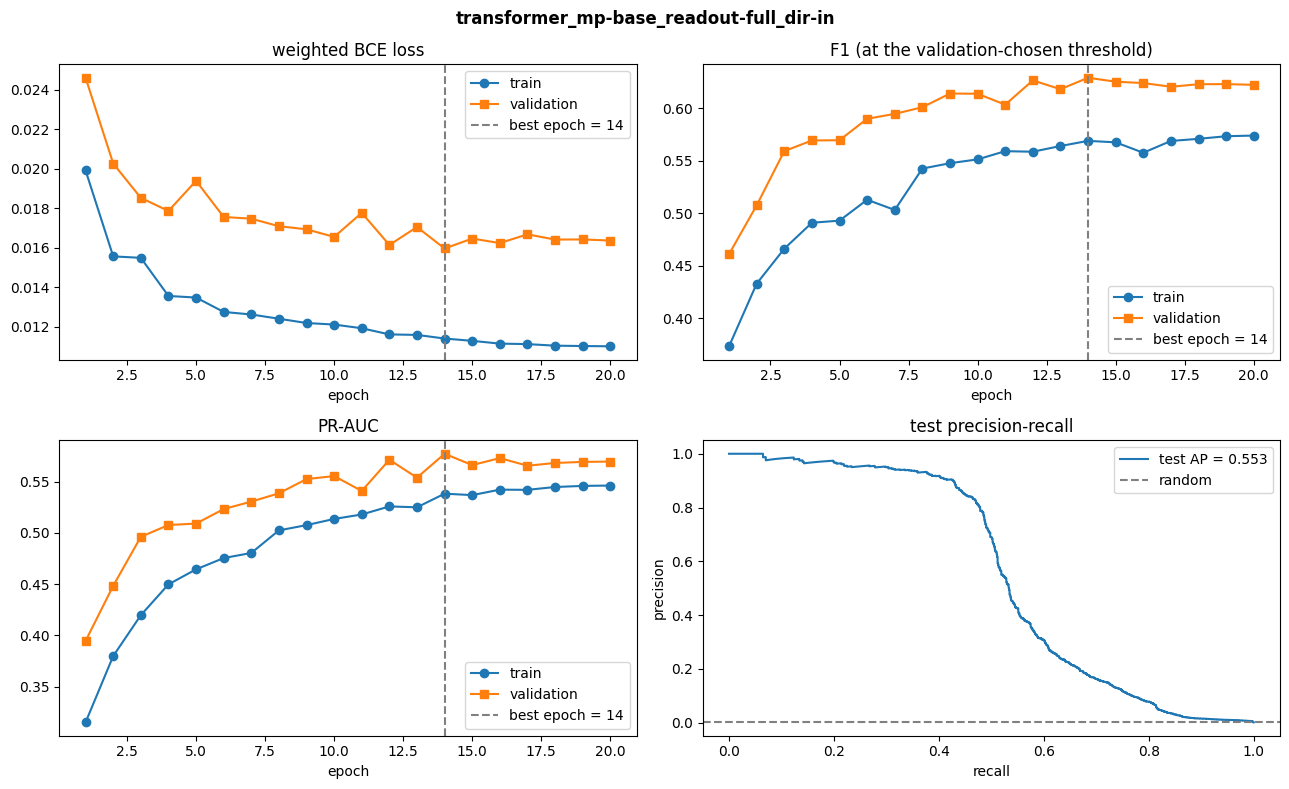

=== transformer_mp-base_readout-gfp_dir-in ===
MP edge features: 20 | readout edge features: 61
total params: 178,945 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0123 / 0.0184 | F1 0.5320 / 0.5771 @ 0.619 | PR-AUC 0.5003 / 0.5156 | 88s | RAM 8.5GB   (train / val)   * new best -> best.pt
best validation F1 0.5771 at epoch 20 (threshold 0.619)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5320  0.5771  0.5341
precision          0.7213  0.7222  0.6331
recall             0.4214  0.4806  0.4619
pr_auc             0.5003  0.5156  0.5080
roc_auc            0.9875  0.9757  0.9757
precision_at_5pct  0.0136  0.0176  0.0191
recall_at_5pct     0.8990  0.8281  0.8495
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-base_readout-gfp_dir-in/predictions.csv


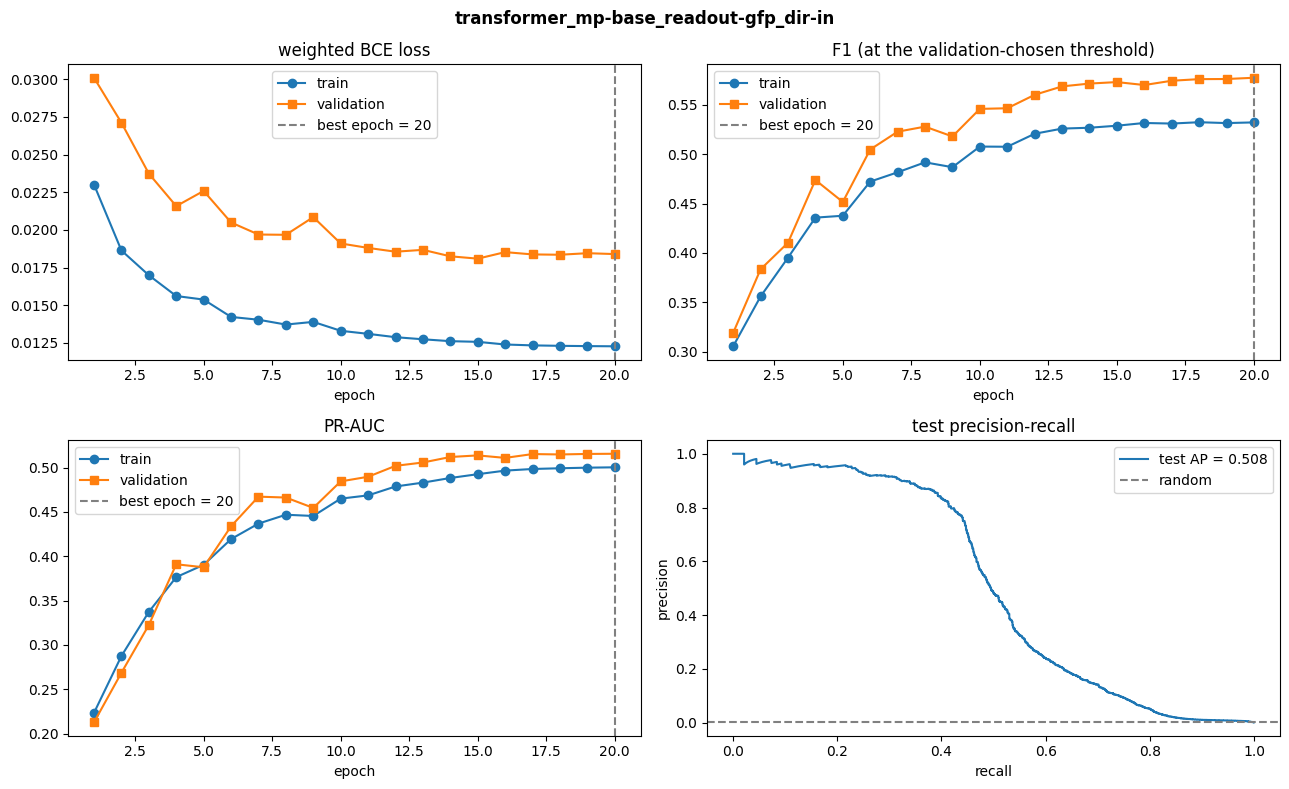

=== transformer_mp-none_readout-gfp_dir-in ===
MP edge features: 0 | readout edge features: 61
total params: 173,825 | architecture-invariant: 133,121


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0224 / 0.0298 | F1 0.2309 / 0.2547 @ 0.389 | PR-AUC 0.1540 / 0.1784 | 65s | RAM 7.6GB   (train / val)   * new best -> best.pt
best validation F1 0.2547 at epoch 20 (threshold 0.389)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.2308  0.2547  0.2037
precision          0.3207  0.2838  0.1702
recall             0.1802  0.2311  0.2537
pr_auc             0.1539  0.1783  0.1391
roc_auc            0.9435  0.9336  0.9270
precision_at_5pct  0.0104  0.0146  0.0148
recall_at_5pct     0.6879  0.6830  0.6588
predictions: 5,077,237 rows -> /kaggle/working/Outputs/TRANSFORMER/transformer_mp-none_readout-gfp_dir-in/predictions.csv


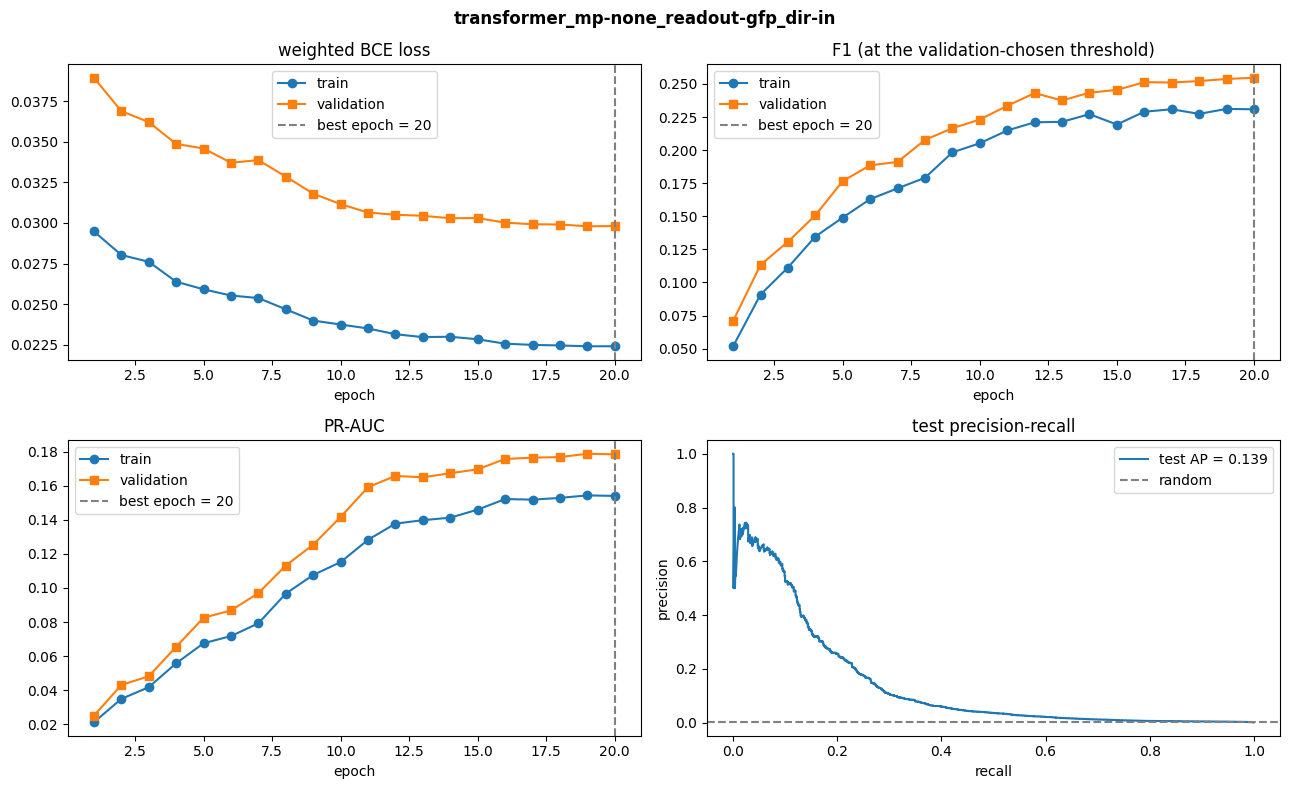

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(OPERATOR, cfg, graphs, col_sets, node_dim, OUT_ROOT,
                                    MP_DIRECTION, TEMPORAL_SAMPLING))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary.csv` holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`.
- `invariant_params` must be identical in every row (asserted).

In [7]:
summary = core.summarize_batch(rows, OUT_ROOT)
summary[core.DISPLAY_COLS].round(4)

7 runs -> /kaggle/working/Outputs/TRANSFORMER/batch_summary.csv | invariant_params = 133,121 in every row


,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,transformer_mp-none_readout-base_dir-in,18,0.2649,0.4267,0.3699,0.3890,0.3526,0.3372,0.0188,0.8346,168577,133121
1,transformer_mp-base_readout-base_dir-in,18,0.5782,0.6243,0.5856,0.8021,0.4611,0.5490,0.0197,0.8731,173697,133121
2,transformer_mp-none_readout-full_dir-in,20,0.4536,0.5112,0.4482,0.5345,0.3858,0.4109,0.0193,0.8556,176385,133121
3,transformer_mp-full_readout-full_dir-in,15,0.6979,0.6440,0.6022,0.7878,0.4873,0.5744,0.0198,0.8810,197121,133121
4,transformer_mp-base_readout-full_dir-in,14,0.6808,0.6287,0.5975,0.8315,0.4663,0.5532,0.0196,0.8714,181505,133121
5,transformer_mp-base_readout-gfp_dir-in,20,0.6192,0.5771,0.5341,0.6331,0.4619,0.5080,0.0191,0.8495,178945,133121
6,transformer_mp-none_readout-gfp_dir-in,20,0.3892,0.2547,0.2037,0.1702,0.2537,0.1391,0.0148,0.6588,173825,133121


## 6. Download

- Zip `OUT_ROOT`; extract into `Outputs/TRANSFORMER/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive(f'/kaggle/working/Outputs_{OPERATOR.upper()}', 'zip', OUT_ROOT)

'/kaggle/working/Outputs_TRANSFORMER.zip'